We continue preparing titanic dataset for NN modeling.

In [32]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../data/titanic_cleaned.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [8]:
df_dummy = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
df_dummy

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
884,0,2,male,27.0,0,0,13.0000,S
885,1,1,female,19.0,0,0,30.0000,S
886,0,3,female,19.0,1,2,23.4500,S
887,1,1,male,26.0,0,0,30.0000,C


In [9]:
df_dummy.dtypes

Survived      int64
Pclass        int64
Sex             str
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked        str
dtype: object

In [10]:
df_dummy = pd.get_dummies(df_dummy)
df_dummy

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,0,3,35.0,0,0,8.0500,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
884,0,2,27.0,0,0,13.0000,False,True,False,False,True
885,1,1,19.0,0,0,30.0000,True,False,False,False,True
886,0,3,19.0,1,2,23.4500,True,False,False,False,True
887,1,1,26.0,0,0,30.0000,False,True,True,False,False


In [11]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
884,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
885,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
886,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,19.0,1,2,W./C. 6607,23.4500,S
887,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [17]:
df.loc[888, "Name"]

'Dooley, Mr. Patrick'

In [18]:
df.iloc[888, 3]

'Dooley, Mr. Patrick'

Adding a new attribute and modifying its value

In [19]:
df ["Newfare"] = 0
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Newfare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [25]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
Newfare          int64
dtype: object

In [26]:
df = df.astype({"Newfare": "float64"})

In [28]:
t0 = time.time()

for index, row in df.iterrows():
    if row["Pclass"] == 1:
        df.loc[index, "Newfare"] = row["Fare"] * 2
    else:
       df.loc[index, "Newfare"] = row["Fare"] * 1.5

t1 = time.time()
print(f"Time taken: {t1 - t0:.5f} seconds")
df.head()

Time taken: 0.24680 seconds


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Newfare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,10.8750
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,142.5666
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,11.8875
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,106.2000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,12.0750


In [29]:
df ["Newfare"] = 0
t0 = time.time()

df[df["Pclass"] == 1]["Newfare"] = df[df["Pclass"] == 1]["Fare"] * 2
df[df["Pclass"] != 1]["Newfare"] = df[df["Pclass"] != 1]["Fare"] * 1.5

t1 = time.time()
print(f"Processing time: {t1-t0:.5f}")

df.head()

Processing time: 0.01634


C:\Users\monat\AppData\Local\Temp\ipykernel_18740\100277985.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  df[df["Pclass"] == 1]["Newfare"] = df[df["Pclass"] == 1]["Fare"] * 2
C:\Users\monat\AppData\Local\Temp\ipykernel_18740\100277985.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are settin

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Newfare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [31]:
t0 = time.time()

df["Newfare"] = np.where(df["Pclass"] == 1, df["Fare"] * 2, df["Fare"] * 1.5)

t1 = time.time()
print(f"It took {t1 - t0:.5f} seconds.")

df.head()

It took 0.00799 seconds.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Newfare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,10.8750
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,142.5666
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,11.8875
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,106.2000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,12.0750


Outlier

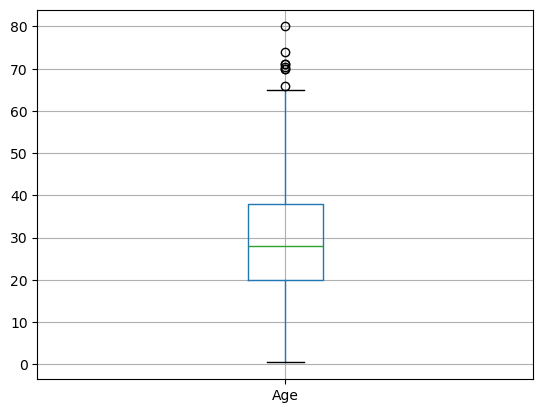

In [33]:
df.boxplot(column=["Age"])
plt.show()

In [35]:
q1 = df["Age"].quantile(0.25)
q3 = df["Age"].quantile(0.75)
q1

np.float64(20.0)

In [36]:
q1 = np.quantile(df["Age"], 0.25)
q3 = np.quantile(df["Age"], 0.75)
q1

np.float64(20.0)

Outlier removal

In [37]:
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR    
upper_bound = q3 + 1.5 * IQR
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Lower bound: -7.0, Upper bound: 65.0


In [39]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Newfare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,29.535624,0.524184,0.382452,32.096681,58.278549
std,256.998173,0.486260,0.834700,14.527483,1.103705,0.806761,49.697504,100.349004
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,20.000000,0.000000,0.000000,7.895800,11.843700
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,21.681300
75%,668.000000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,55.441600
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1024.658400


In [40]:
df.shape

(889, 12)

In [41]:
# remove the age outliers
df = df[(df["Age"] >= lower_bound) & (df["Age"] <= upper_bound)]

In [42]:
df.shape

(881, 12)

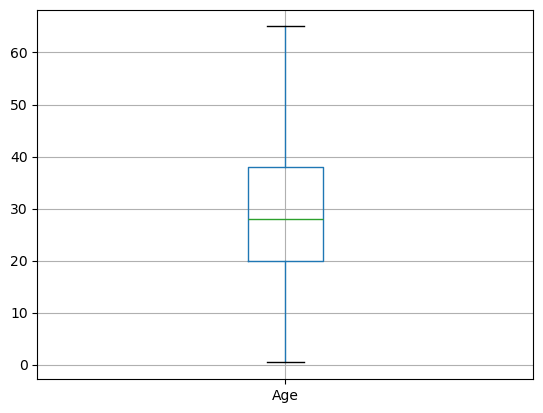

In [43]:
df.boxplot(column=["Age"])
plt.show()

In [44]:
df.to_csv("../data/titanic_prepared.csv", index=False)